In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score
)
from xgboost import XGBClassifier

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print(f'Shape: {X.shape}')
print(f'Classes: {np.unique(y)}')
print(f'Amostras por classe: {np.bincount(y)}')

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Amostras por classe: [178 182 177 183 181 182 181 179 174 180]


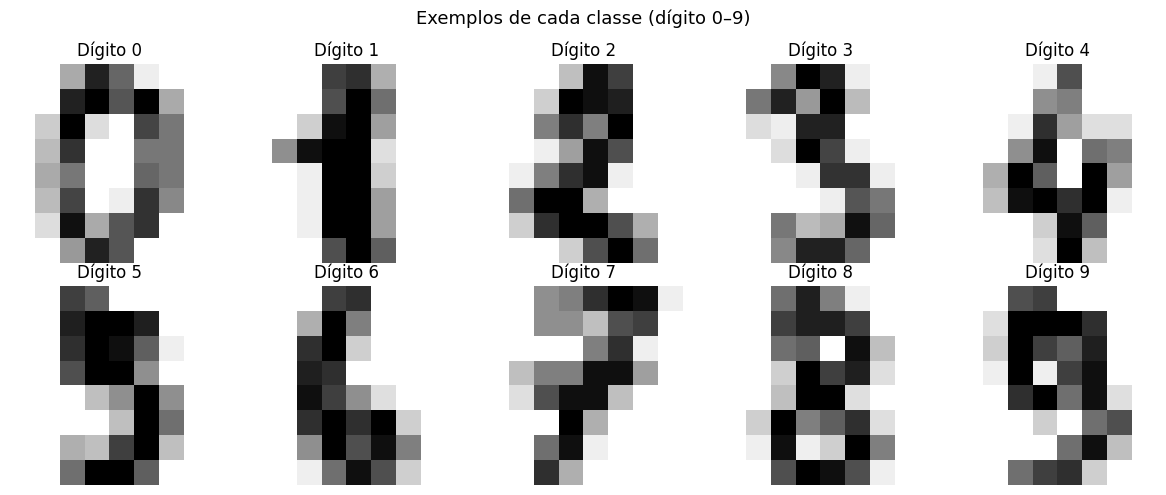

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), range(10)):
    sample = X[y == idx][0].reshape(8, 8)
    ax.imshow(sample, cmap='gray_r')
    ax.set_title(f'Dígito {idx}')
    ax.axis('off')
plt.suptitle('Exemplos de cada classe (dígito 0–9)', fontsize=13)
plt.tight_layout()
plt.show()

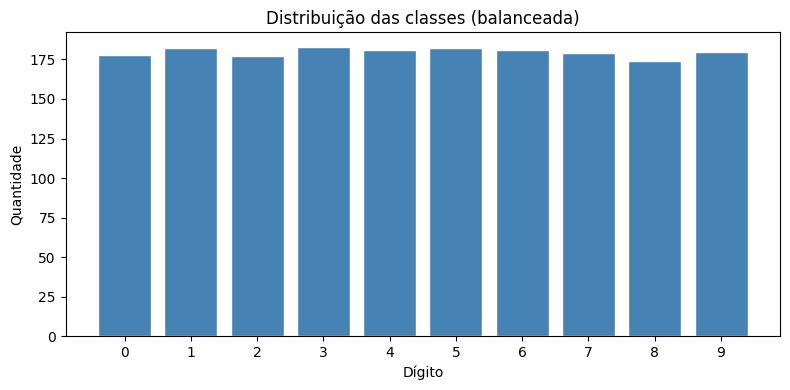

In [4]:
# Distribuição das classes
plt.figure(figsize=(8, 4))
plt.bar(range(10), np.bincount(y), color='steelblue', edgecolor='white')
plt.xlabel('Dígito')
plt.ylabel('Quantidade')
plt.title('Distribuição das classes (balanceada)')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 1437 amostras
Teste:  360 amostras


In [6]:
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_treino, y_treino)
print(f'Melhores Parâmetros RF: {grid_rf.best_params_}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Melhores Parâmetros RF: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


F1 Score Random Forest (weighted): 96.92%
Taxa de Erro: 3.06%



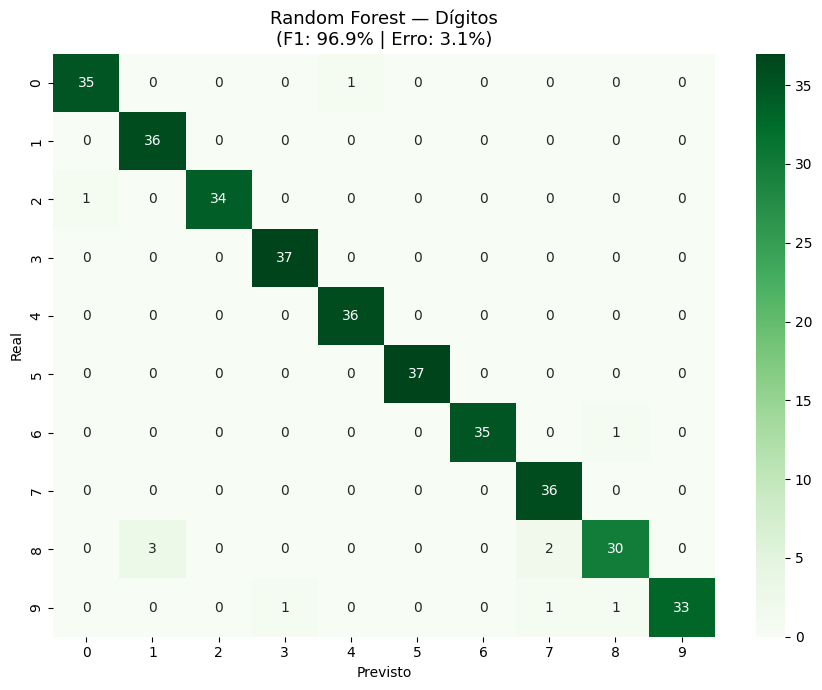

In [7]:
modelo = RandomForestClassifier(**grid_rf.best_params_, random_state=42, n_jobs=-1)
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

f1 = f1_score(y_teste, previsoes, average='weighted')
acc = accuracy_score(y_teste, previsoes)
print(f'F1 Score Random Forest (weighted): {f1 * 100:.2f}%')
print(f'Taxa de Erro: {(1 - acc) * 100:.2f}%\n')

plt.figure(figsize=(9, 7))
matriz_rf = confusion_matrix(y_teste, previsoes)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens')
plt.title(f'Random Forest — Dígitos\n(F1: {f1*100:.1f}% | Erro: {(1-acc)*100:.1f}%)', fontsize=13)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [8]:
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    tree_method='hist',
    num_class=10,
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1
)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_xgb.fit(X_treino, y_treino)
print(f'Melhores Parâmetros XGB: {grid_xgb.best_params_}')

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Melhores Parâmetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}


F1 Score XGBoost (weighted): 96.63%
Taxa de Erro: 3.33%



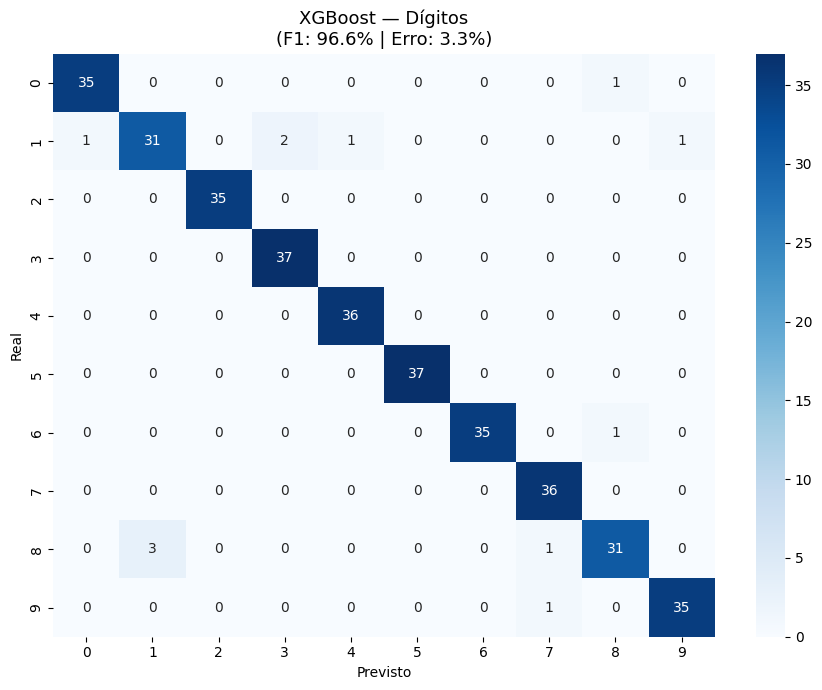

In [9]:
modelo_xgb = XGBClassifier(
    **grid_xgb.best_params_,
    tree_method='hist',
    num_class=10,
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_treino, y_treino)

previsoes_xgb = modelo_xgb.predict(X_teste)

f1_xgb = f1_score(y_teste, previsoes_xgb, average='weighted')
acc_xgb = accuracy_score(y_teste, previsoes_xgb)
print(f'F1 Score XGBoost (weighted): {f1_xgb * 100:.2f}%')
print(f'Taxa de Erro: {(1 - acc_xgb) * 100:.2f}%\n')

plt.figure(figsize=(9, 7))
matriz_xgb = confusion_matrix(y_teste, previsoes_xgb)
sns.heatmap(matriz_xgb, annot=True, fmt='d', cmap='Blues')
plt.title(f'XGBoost — Dígitos\n(F1: {f1_xgb*100:.1f}% | Erro: {(1-acc_xgb)*100:.1f}%)', fontsize=13)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [10]:
# --- Análise de Overfitting: Treino vs Teste ---

# Predições no conjunto de TREINO
prev_treino_rf  = modelo.predict(X_treino)
prev_treino_xgb = modelo_xgb.predict(X_treino)

# Multiclasse: average='weighted' em todos
f1_treino_rf   = f1_score(y_treino, prev_treino_rf,  average='weighted')
acc_treino_rf  = accuracy_score(y_treino, prev_treino_rf)
f1_treino_xgb  = f1_score(y_treino, prev_treino_xgb, average='weighted')
acc_treino_xgb = accuracy_score(y_treino, prev_treino_xgb)

f1_teste_rf   = f1_score(y_teste, previsoes,     average='weighted')
acc_teste_rf  = accuracy_score(y_teste, previsoes)
f1_teste_xgb  = f1_score(y_teste, previsoes_xgb, average='weighted')
acc_teste_xgb = accuracy_score(y_teste, previsoes_xgb)

print('=' * 52)
print(f'{'':>20} {'TREINO':>10} {'TESTE':>10}')
print('=' * 52)
print(f'{'RF  — F1 Score':>20} {f1_treino_rf*100:>9.2f}% {f1_teste_rf*100:>9.2f}%')
print(f'{'RF  — Acurácia':>20} {acc_treino_rf*100:>9.2f}% {acc_teste_rf*100:>9.2f}%')
print('-' * 52)
print(f'{'XGB — F1 Score':>20} {f1_treino_xgb*100:>9.2f}% {f1_teste_xgb*100:>9.2f}%')
print(f'{'XGB — Acurácia':>20} {acc_treino_xgb*100:>9.2f}% {acc_teste_xgb*100:>9.2f}%')
print('=' * 52)
print()
print(f'Diferença RF  (treino - teste) F1:  {(f1_treino_rf  - f1_teste_rf)*100:+.2f}%')
print(f'Diferença XGB (treino - teste) F1:  {(f1_treino_xgb - f1_teste_xgb)*100:+.2f}%')
print()
print('Interpretação:')
print('  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)')
print('  Diferença grande  (> 10%) => possível overfitting')

                         TREINO      TESTE
      RF  — F1 Score    100.00%     96.92%
      RF  — Acurácia    100.00%     96.94%
----------------------------------------------------
      XGB — F1 Score    100.00%     96.63%
      XGB — Acurácia    100.00%     96.67%

Diferença RF  (treino - teste) F1:  +3.08%
Diferença XGB (treino - teste) F1:  +3.37%

Interpretação:
  Diferença pequena (< 5%)  => modelo generaliza bem (sem overfitting)
  Diferença grande  (> 10%) => possível overfitting


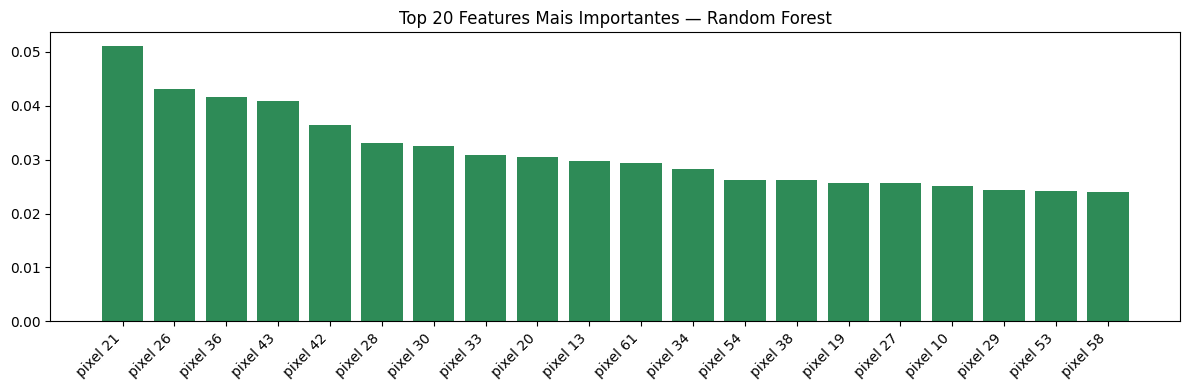

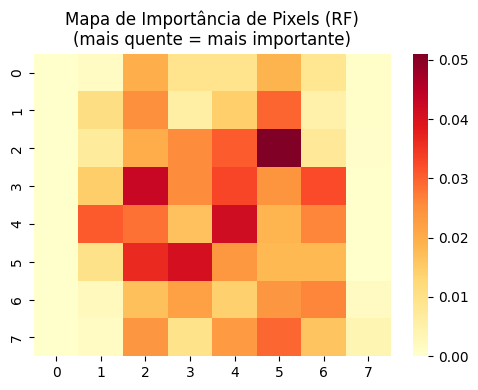

In [11]:
# Importância das features — Top 20 pixels mais relevantes (RF)
importancias = modelo.feature_importances_
top20_idx = np.argsort(importancias)[::-1][:20]

plt.figure(figsize=(12, 4))
plt.bar(range(20), importancias[top20_idx], color='seagreen')
plt.xticks(range(20), [f'pixel {i}' for i in top20_idx], rotation=45, ha='right')
plt.title('Top 20 Features Mais Importantes — Random Forest')
plt.tight_layout()
plt.show()

# Visualizar quais pixels são mais importantes no grid 8x8
mapa = importancias.reshape(8, 8)
plt.figure(figsize=(5, 4))
sns.heatmap(mapa, cmap='YlOrRd', annot=False)
plt.title('Mapa de Importância de Pixels (RF)\n(mais quente = mais importante)')
plt.tight_layout()
plt.show()